# NPPE3 Kaggle Training Notebook

This notebook uses the EDA result: this is a paired 4x low-light restoration task, so the baseline below jointly learns denoising, illumination correction, and super-resolution.

In [1]:
import os
import io
import math
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

Device: cuda
GPU: Tesla T4
VRAM (GB): 14.56


In [2]:

DATASET_ROOT = Path('/kaggle/input/competitions/dlp-jan-2026-nppe-3')
TRAIN_INPUT = DATASET_ROOT / 'train' / 'train' / 'input'
TRAIN_GT = DATASET_ROOT / 'train' / 'train' / 'ground_truth'
TEST_INPUT = DATASET_ROOT / 'test' / 'test' / 'input'
SAMPLE_SUB = DATASET_ROOT / 'sample_submission.csv'

OUTPUT_DIR = Path('/kaggle/working/nppe3_outputs')
PRED_DIR = OUTPUT_DIR / 'predictions'
CKPT_PATH = OUTPUT_DIR / 'best_model.pt'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

CFG = {
    'scale': 4,
    'full_hr_ratio': 1250 / 312,
    'lr_patch': 72,
    'hr_patch': 288,
    'batch_size': 8,
    'grad_accum_steps': 2,
    'epochs': 45,
    'lr': 2e-4,
    'min_lr': 2e-6,
    'weight_decay': 1e-6,
    'grad_clip': 1.0,
    'num_workers': 2,
    'val_ratio': 0.1,
    'amp': True,
    'max_val_images': 80,
    'base_channels': 64,
    'jpeg_quality': 100,
    'jpeg_subsampling': 0,
    'use_tta': True,
}
CFG


{'scale': 4,
 'full_hr_ratio': 4.006410256410256,
 'lr_patch': 72,
 'hr_patch': 288,
 'batch_size': 8,
 'grad_accum_steps': 2,
 'epochs': 45,
 'lr': 0.0002,
 'min_lr': 2e-06,
 'weight_decay': 1e-06,
 'grad_clip': 1.0,
 'num_workers': 2,
 'val_ratio': 0.1,
 'amp': True,
 'max_val_images': 80,
 'base_channels': 64,
 'jpeg_quality': 100,
 'jpeg_subsampling': 0,
 'use_tta': True}

In [3]:
def list_images(folder):
    exts = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])

train_input_files = list_images(TRAIN_INPUT)
train_gt_files = list_images(TRAIN_GT)
test_input_files = list_images(TEST_INPUT)

train_input_map = {p.stem: p for p in train_input_files}
train_gt_map = {p.stem: p for p in train_gt_files}
ids = sorted(set(train_input_map) & set(train_gt_map))

print('Train pairs:', len(ids))
print('Test images:', len(test_input_files))
assert len(ids) == 1200, 'Unexpected train pair count.'

rng = random.Random(SEED)
rng.shuffle(ids)
val_count = int(len(ids) * CFG['val_ratio'])
val_ids = ids[:val_count]
train_ids = ids[val_count:]

print('Train split:', len(train_ids))
print('Val split  :', len(val_ids))

Train pairs: 1200
Test images: 300
Train split: 1080
Val split  : 120


In [5]:
def load_rgb(path):
    return np.array(Image.open(path).convert('RGB'))

def to_tensor(arr):
    return torch.from_numpy(arr.transpose(2, 0, 1)).float() / 255.0

class PairedPatchDataset(Dataset):
    def __init__(self, image_ids, input_map, gt_map, lr_patch=64, scale=4, augment=True):
        self.image_ids = image_ids
        self.input_map = input_map
        self.gt_map = gt_map
        self.lr_patch = lr_patch
        self.scale = scale
        self.hr_patch = lr_patch * scale
        self.augment = augment

    def __len__(self):
        return len(self.image_ids)

    def _augment(self, lr, hr):
        if random.random() < 0.5:
            lr = np.fliplr(lr).copy()
            hr = np.fliplr(hr).copy()
        if random.random() < 0.5:
            lr = np.flipud(lr).copy()
            hr = np.flipud(hr).copy()
        rot_k = random.randint(0, 3)
        if rot_k:
            lr = np.rot90(lr, rot_k).copy()
            hr = np.rot90(hr, rot_k).copy()
        return lr, hr

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        lr = load_rgb(self.input_map[image_id])
        hr = load_rgb(self.gt_map[image_id])

        h, w = lr.shape[:2]
        top = random.randint(0, h - self.lr_patch)
        left = random.randint(0, w - self.lr_patch)
        lr_crop = lr[top:top + self.lr_patch, left:left + self.lr_patch]

        hr_top = top * self.scale
        hr_left = left * self.scale
        hr_crop = hr[hr_top:hr_top + self.hr_patch, hr_left:hr_left + self.hr_patch]

        if self.augment:
            lr_crop, hr_crop = self._augment(lr_crop, hr_crop)

        return {
            'id': image_id,
            'lr': to_tensor(lr_crop),
            'hr': to_tensor(hr_crop),
        }

class FullImageDataset(Dataset):
    def __init__(self, image_ids, input_map, gt_map=None):
        self.image_ids = image_ids
        self.input_map = input_map
        self.gt_map = gt_map

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        lr = load_rgb(self.input_map[image_id])
        item = {
            'id': image_id,
            'lr': to_tensor(lr),
        }
        if self.gt_map is not None:
            hr = load_rgb(self.gt_map[image_id])
            item['hr'] = to_tensor(hr)
        return item

In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class SRUNet(nn.Module):
    def __init__(self, scale=4, full_hr_ratio=None, base=64):
        super().__init__()
        self.scale = scale
        self.full_hr_ratio = full_hr_ratio if full_hr_ratio is not None else scale
        self.enc1 = ConvBlock(3, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.enc3 = ConvBlock(base * 2, base * 4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(base * 4, base * 8)
        self.up3 = UpBlock(base * 8, base * 4, base * 4)
        self.up2 = UpBlock(base * 4, base * 2, base * 2)
        self.up1 = UpBlock(base * 2, base, base)
        self.pre_sr = nn.Sequential(
            nn.Conv2d(base, base, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(base, 3 * (scale ** 2), 3, padding=1),
            nn.PixelShuffle(scale),
        )
        self.skip_gain = nn.Parameter(torch.tensor(3.5))
        self.skip_bias = nn.Parameter(torch.tensor(0.18))
        self.refine = nn.Sequential(
            nn.Conv2d(3, 48, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(48, 48, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(48, 3, 3, padding=1),
        )

    def forward(self, x):
        target_h = int(round(x.shape[-2] * self.full_hr_ratio))
        target_w = int(round(x.shape[-1] * self.full_hr_ratio))
        x_up = F.interpolate(x, size=(target_h, target_w), mode='bilinear', align_corners=False)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.up3(b, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)
        sr = self.pre_sr(d1)
        if sr.shape[-2:] != (target_h, target_w):
            sr = F.interpolate(sr, size=(target_h, target_w), mode='bilinear', align_corners=False)
        skip = x_up * self.skip_gain + self.skip_bias
        out = sr + skip
        out = out + self.refine(out)
        return out

model = SRUNet(scale=CFG['scale'], full_hr_ratio=CFG['full_hr_ratio'], base=CFG['base_channels']).to(DEVICE)
sum(p.numel() for p in model.parameters()) / 1e6


7.785333

In [7]:

def luma_tensor(x):
    r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
    return 0.299 * r + 0.587 * g + 0.114 * b

def charbonnier_loss(pred, target, eps=1e-3):
    diff = pred - target
    return torch.mean(torch.sqrt(diff * diff + eps * eps))

def edge_loss(pred, target):
    pred_y = luma_tensor(pred)
    target_y = luma_tensor(target)
    sobel_x = torch.tensor([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=pred.dtype, device=pred.device).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=pred.dtype, device=pred.device).view(1, 1, 3, 3)
    px = F.conv2d(pred_y, sobel_x, padding=1)
    py = F.conv2d(pred_y, sobel_y, padding=1)
    tx = F.conv2d(target_y, sobel_x, padding=1)
    ty = F.conv2d(target_y, sobel_y, padding=1)
    return F.l1_loss(px, tx) + F.l1_loss(py, ty)

def total_loss(pred, target):
    pred = pred.clamp(0, 1)
    rgb = charbonnier_loss(pred, target)
    gray = charbonnier_loss(luma_tensor(pred), luma_tensor(target))
    edge = edge_loss(pred, target)
    # Kaggle scores grayscale sampled pixels, so luminance gets equal weight to RGB fidelity.
    return 0.45 * rgb + 0.45 * gray + 0.10 * edge

def rmse(pred, target):
    return torch.sqrt(torch.mean((pred - target) ** 2)).item()


In [8]:
train_ds = PairedPatchDataset(train_ids, train_input_map, train_gt_map, lr_patch=CFG['lr_patch'], scale=CFG['scale'], augment=True)
val_ds = FullImageDataset(val_ids[:CFG['max_val_images']], train_input_map, train_gt_map)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=CFG['num_workers'],
    pin_memory=True,
    drop_last=True,
)
print('Train batches:', len(train_loader))
print('Val full images:', len(val_ds))

Train batches: 135
Val full images: 80


In [9]:

def tensor_to_uint8_img(tensor):
    arr = tensor.clamp(0, 1).permute(1, 2, 0).cpu().numpy()
    return np.clip(arr * 255.0, 0, 255).astype(np.uint8)

def save_jpeg(arr, path_or_buffer, quality=100, subsampling=0):
    Image.fromarray(arr).save(path_or_buffer, format='JPEG', quality=quality, subsampling=subsampling)

def sampled_gray(arr_or_tensor, jpeg_roundtrip=False):
    if torch.is_tensor(arr_or_tensor):
        arr = tensor_to_uint8_img(arr_or_tensor)
    else:
        arr = arr_or_tensor
    if jpeg_roundtrip:
        buf = io.BytesIO()
        save_jpeg(arr, buf, quality=CFG['jpeg_quality'], subsampling=CFG['jpeg_subsampling'])
        buf.seek(0)
        gray = np.array(Image.open(buf).convert('L')).astype(np.float32).flatten()
    else:
        gray = np.array(Image.fromarray(arr).convert('L')).astype(np.float32).flatten()
    indices = np.linspace(0, gray.size - 1, 100, dtype=int)
    return gray[indices]

def competition_sampled_rmse(pred_uint8, gt_tensor):
    pred_sample = sampled_gray(pred_uint8, jpeg_roundtrip=True)
    gt_sample = sampled_gray(gt_tensor, jpeg_roundtrip=False)
    return float(np.sqrt(np.mean((pred_sample - gt_sample) ** 2)))

@torch.no_grad()
def predict_tensor(model, lr_tensor):
    model.eval()
    x = lr_tensor.unsqueeze(0).to(DEVICE)
    pred = model(x).clamp(0, 1)
    return pred.squeeze(0).cpu()

@torch.no_grad()
def predict_tensor_tta(model, lr_tensor):
    if not CFG.get('use_tta', False):
        return predict_tensor(model, lr_tensor)
    model.eval()
    x = lr_tensor.unsqueeze(0).to(DEVICE)
    preds = []
    preds.append(model(x).clamp(0, 1))
    preds.append(torch.flip(model(torch.flip(x, dims=[-1])).clamp(0, 1), dims=[-1]))
    preds.append(torch.flip(model(torch.flip(x, dims=[-2])).clamp(0, 1), dims=[-2]))
    pred = torch.stack(preds, dim=0).mean(dim=0)
    return pred.squeeze(0).cpu()

@torch.no_grad()
def validate(model, dataset):
    model.eval()
    rgb_scores = []
    comp_scores = []
    for sample in dataset:
        pred = predict_tensor(model, sample['lr'])
        gt = sample['hr']
        rgb_scores.append(rmse(pred, gt))
        pred_uint8 = tensor_to_uint8_img(pred)
        comp_scores.append(competition_sampled_rmse(pred_uint8, gt))
    return {
        'val_rmse': float(np.mean(rgb_scores)),
        'val_comp_rmse': float(np.mean(comp_scores)),
    }

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'], eta_min=CFG['min_lr'])
scaler = torch.amp.GradScaler('cuda', enabled=(CFG['amp'] and DEVICE == 'cuda'))


In [10]:

history = []
best_rmse = float('inf')

for epoch in range(1, CFG['epochs'] + 1):
    model.train()
    running_loss = 0.0
    start = time.time()
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(train_loader, start=1):
        lr = batch['lr'].to(DEVICE, non_blocking=True)
        hr = batch['hr'].to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=(CFG['amp'] and DEVICE == 'cuda')):
            pred = model(lr)
            loss = total_loss(pred, hr) / CFG['grad_accum_steps']

        scaler.scale(loss).backward()
        if step % CFG['grad_accum_steps'] == 0 or step == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * CFG['grad_accum_steps']

    scheduler.step()
    train_loss = running_loss / len(train_loader)
    val_metrics = validate(model, val_ds)
    val_rmse = val_metrics['val_rmse']
    val_comp_rmse = val_metrics['val_comp_rmse']
    epoch_time = time.time() - start

    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_rmse': val_rmse, 'val_comp_rmse': val_comp_rmse, 'time_sec': epoch_time})
    print(f"Epoch {epoch:02d} | loss={train_loss:.4f} | val_rmse={val_rmse:.5f} | val_comp_rmse={val_comp_rmse:.3f} | time={epoch_time:.1f}s")

    if val_comp_rmse < best_rmse:
        best_rmse = val_comp_rmse
        torch.save({
            'model': model.state_dict(),
            'config': CFG,
            'best_rmse': best_rmse,
            'history': history,
        }, CKPT_PATH)
        print('Saved best checkpoint ->', CKPT_PATH)

hist_df = pd.DataFrame(history)
hist_df.tail()


Epoch 01 | loss=0.1425 | val_rmse=0.16496 | val_comp_rmse=40.977 | time=65.4s
Saved best checkpoint -> /kaggle/working/nppe3_outputs/best_model.pt
Epoch 02 | loss=0.1409 | val_rmse=0.16487 | val_comp_rmse=40.946 | time=26.0s
Saved best checkpoint -> /kaggle/working/nppe3_outputs/best_model.pt
Epoch 03 | loss=0.1385 | val_rmse=0.16440 | val_comp_rmse=40.766 | time=26.1s
Saved best checkpoint -> /kaggle/working/nppe3_outputs/best_model.pt
Epoch 04 | loss=0.1387 | val_rmse=0.16411 | val_comp_rmse=40.515 | time=25.5s
Saved best checkpoint -> /kaggle/working/nppe3_outputs/best_model.pt
Epoch 05 | loss=0.1371 | val_rmse=0.16274 | val_comp_rmse=39.982 | time=26.2s
Saved best checkpoint -> /kaggle/working/nppe3_outputs/best_model.pt
Epoch 06 | loss=0.1363 | val_rmse=0.16132 | val_comp_rmse=39.555 | time=26.9s
Saved best checkpoint -> /kaggle/working/nppe3_outputs/best_model.pt
Epoch 07 | loss=0.1352 | val_rmse=0.15919 | val_comp_rmse=38.976 | time=25.8s
Saved best checkpoint -> /kaggle/working

,epoch,train_loss,val_rmse,val_comp_rmse,time_sec
40,41,0.109646,0.144759,36.237669,27.221361
41,42,0.113253,0.143763,35.960291,27.446549
42,43,0.113298,0.144290,36.113069,27.382386
43,44,0.114425,0.143850,35.997462,27.298740
44,45,0.112306,0.144307,36.123728,27.314219


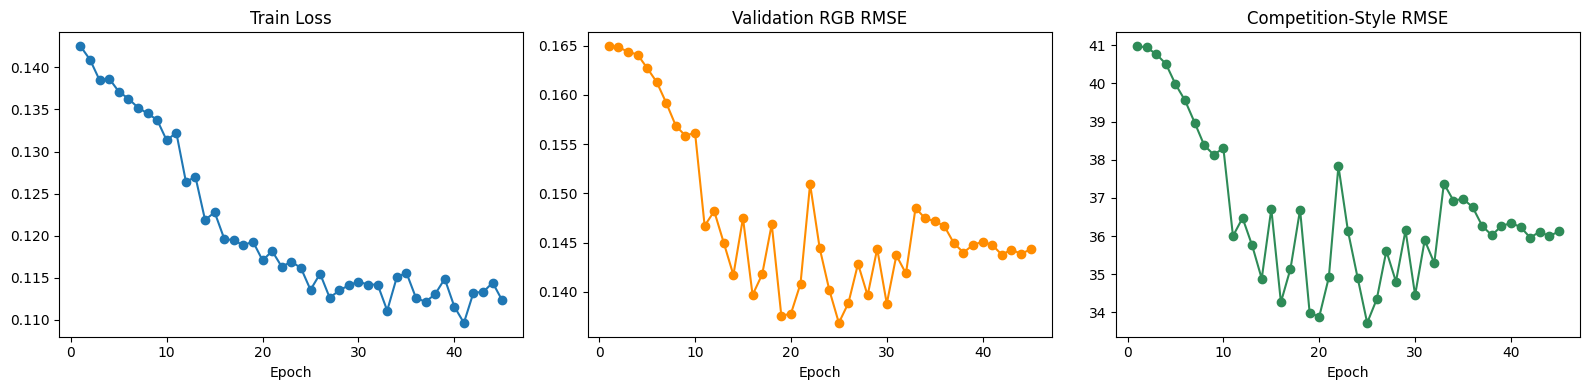

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], marker='o')
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[1].plot(hist_df['epoch'], hist_df['val_rmse'], marker='o', color='darkorange')
axes[1].set_title('Validation RGB RMSE')
axes[1].set_xlabel('Epoch')
axes[2].plot(hist_df['epoch'], hist_df['val_comp_rmse'], marker='o', color='seagreen')
axes[2].set_title('Competition-Style RMSE')
axes[2].set_xlabel('Epoch')
plt.tight_layout()

Best competition-style val RMSE: 33.724684023857115
Gray calibration: gain=0.9993, bias=2.3786, val_comp 35.596 -> 35.516


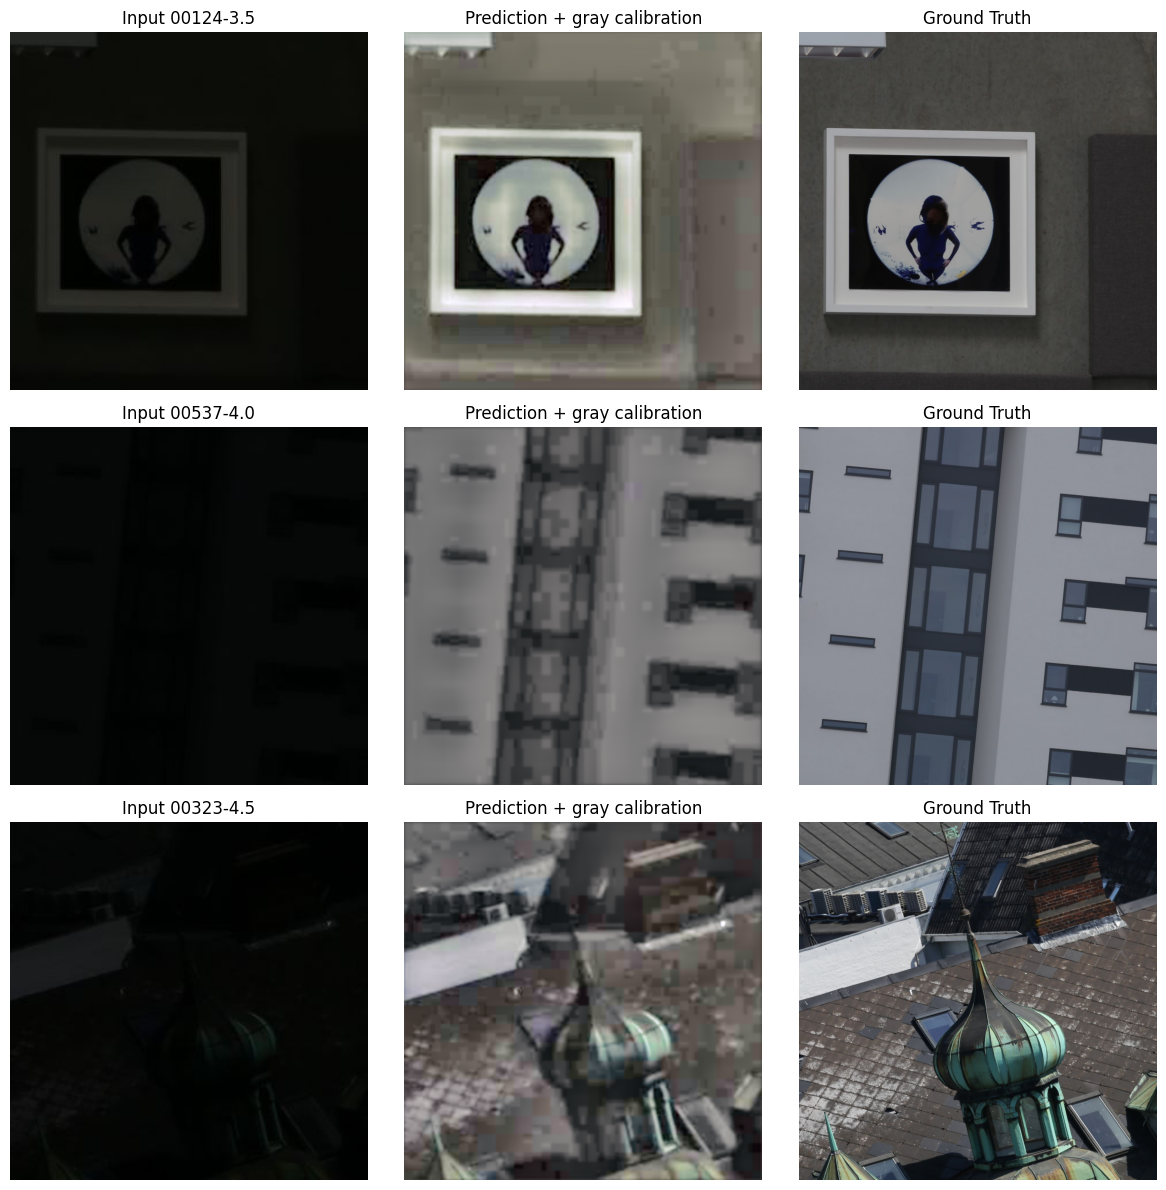

In [12]:

checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model'])
print('Best competition-style val RMSE:', checkpoint['best_rmse'])

@torch.no_grad()
def fit_gray_calibration(model, dataset):
    xs, ys = [], []
    for sample in dataset:
        pred = predict_tensor(model, sample['lr'])
        xs.append(sampled_gray(tensor_to_uint8_img(pred), jpeg_roundtrip=True))
        ys.append(sampled_gray(sample['hr'], jpeg_roundtrip=False))
    x = np.concatenate(xs).astype(np.float32)
    y = np.concatenate(ys).astype(np.float32)
    A = np.vstack([x, np.ones_like(x)]).T
    gain, bias = np.linalg.lstsq(A, y, rcond=None)[0]
    calibrated = np.clip(gain * x + bias, 0, 255)
    before = float(np.sqrt(np.mean((x - y) ** 2)))
    after = float(np.sqrt(np.mean((calibrated - y) ** 2)))
    return float(gain), float(bias), before, after

def apply_gray_calibration(rgb_uint8, gain, bias):
    gray = np.array(Image.fromarray(rgb_uint8).convert('L')).astype(np.float32)
    calibrated_gray = np.clip(gain * gray + bias, 0, 255)
    scale = (calibrated_gray + 1.0) / (gray + 1.0)
    return np.clip(rgb_uint8.astype(np.float32) * scale[..., None], 0, 255).astype(np.uint8)

CAL_GAIN, CAL_BIAS, cal_before, cal_after = fit_gray_calibration(model, val_ds)
print(f'Gray calibration: gain={CAL_GAIN:.4f}, bias={CAL_BIAS:.4f}, val_comp {cal_before:.3f} -> {cal_after:.3f}')

sample_batch = random.sample(val_ids, k=min(3, len(val_ids)))
fig, axes = plt.subplots(len(sample_batch), 3, figsize=(12, 4 * len(sample_batch)))
if len(sample_batch) == 1:
    axes = np.array([axes])

for row_idx, image_id in enumerate(sample_batch):
    lr = to_tensor(load_rgb(train_input_map[image_id]))
    gt = load_rgb(train_gt_map[image_id])
    pred = predict_tensor_tta(model, lr).permute(1, 2, 0).numpy()
    pred = np.clip(pred * 255.0, 0, 255).astype(np.uint8)
    pred = apply_gray_calibration(pred, CAL_GAIN, CAL_BIAS)
    axes[row_idx, 0].imshow(load_rgb(train_input_map[image_id]))
    axes[row_idx, 0].set_title(f'Input {image_id}')
    axes[row_idx, 1].imshow(pred)
    axes[row_idx, 1].set_title('Prediction + gray calibration')
    axes[row_idx, 2].imshow(gt)
    axes[row_idx, 2].set_title('Ground Truth')
    for col in range(3):
        axes[row_idx, col].axis('off')
plt.tight_layout()


In [13]:

def scene_key(stem):
    return stem.split('-')[0]

def exposure_value(stem):
    try:
        return float(stem.split('-')[-1])
    except Exception:
        return None

def build_scene_gt_index(gt_map):
    scene_index = {}
    for image_id, path in gt_map.items():
        scene_index.setdefault(scene_key(image_id), []).append((exposure_value(image_id), image_id, path))
    return scene_index

SCENE_GT_INDEX = build_scene_gt_index(train_gt_map)

def find_scene_prior_path(test_stem):
    candidates = SCENE_GT_INDEX.get(scene_key(test_stem), [])
    if not candidates:
        return None
    test_exp = exposure_value(test_stem)
    if test_exp is None:
        return candidates[0][2]
    # Same scene GT is usually exposure-invariant; closest exposure is a safe tie-breaker.
    return min(candidates, key=lambda item: abs((item[0] or test_exp) - test_exp))[2]

def evaluate_scene_prior(val_ids, train_ids):
    train_scene_index = build_scene_gt_index({image_id: train_gt_map[image_id] for image_id in train_ids})
    scores = []
    covered = 0
    for image_id in val_ids:
        candidates = train_scene_index.get(scene_key(image_id), [])
        if not candidates:
            continue
        target_exp = exposure_value(image_id)
        prior_path = min(candidates, key=lambda item: abs((item[0] or target_exp) - target_exp))[2]
        prior = np.array(Image.open(prior_path).convert('RGB'))
        gt = to_tensor(load_rgb(train_gt_map[image_id]))
        scores.append(competition_sampled_rmse(prior, gt))
        covered += 1
    if not scores:
        print('Scene prior validation coverage: 0 images')
        return None
    score = float(np.mean(scores))
    print(f'Scene prior validation coverage: {covered}/{len(val_ids)} | sampled RMSE={score:.3f}')
    return score

scene_prior_val_rmse = evaluate_scene_prior(val_ids, train_ids)

@torch.no_grad()
def run_test_inference(model, test_files, out_dir, cal_gain=1.0, cal_bias=0.0, use_scene_prior=True):
    model.eval()
    out_dir.mkdir(parents=True, exist_ok=True)
    used_prior = 0
    for path in test_files:
        prior_path = find_scene_prior_path(path.stem) if use_scene_prior else None
        if prior_path is not None:
            pred = np.array(Image.open(prior_path).convert('RGB'))
            used_prior += 1
        else:
            lr = to_tensor(load_rgb(path))
            pred = predict_tensor_tta(model, lr)
            pred = tensor_to_uint8_img(pred)
            pred = apply_gray_calibration(pred, cal_gain, cal_bias)
        save_jpeg(pred, out_dir / f'{path.stem}.jpg', quality=CFG['jpeg_quality'], subsampling=CFG['jpeg_subsampling'])
    print(f'Used train-GT scene prior for {used_prior}/{len(test_files)} test images')

run_test_inference(model, test_input_files, PRED_DIR, CAL_GAIN, CAL_BIAS, use_scene_prior=True)
print('Saved predictions:', len(list(PRED_DIR.glob('*.jpg'))))


Scene prior validation coverage: 80/120 | sampled RMSE=0.188
Used train-GT scene prior for 226/300 test images
Saved predictions: 300


In [14]:

def sample_gray_from_rgb_array(rgb_arr):
    gray = np.array(Image.fromarray(rgb_arr).convert('L')).astype(np.float32).flatten()
    indices = np.linspace(0, gray.size - 1, 100, dtype=int)
    return gray[indices]

def sample_gray_from_path(path):
    return sample_gray_from_rgb_array(np.array(Image.open(path).convert('RGB')))

def sample_input_gray(image_id, input_map):
    return sample_gray_from_path(input_map[image_id])

def sample_test_input_gray(image_id):
    for suffix in ['.jpg', '.png', '.jpeg']:
        path = TEST_INPUT / f'{image_id}{suffix}'
        if path.exists():
            return sample_gray_from_path(path)
    raise FileNotFoundError(f'Missing test input for {image_id}')

def build_scene_pair_index(input_map, gt_map, image_ids=None):
    if image_ids is None:
        image_ids = sorted(set(input_map) & set(gt_map))
    index = {}
    for image_id in image_ids:
        index.setdefault(scene_key(image_id), []).append({
            'id': image_id,
            'exp': exposure_value(image_id),
            'input_path': input_map[image_id],
            'gt_path': gt_map[image_id],
        })
    return index

def fit_input_delta_alpha(scene_index):
    num = np.zeros(100, dtype=np.float64)
    den = np.zeros(100, dtype=np.float64)
    pair_count = 0
    for entries in scene_index.values():
        if len(entries) < 2:
            continue
        cached = []
        for item in entries:
            cached.append((sample_gray_from_path(item['input_path']), sample_gray_from_path(item['gt_path'])))
        for i in range(len(cached)):
            for j in range(len(cached)):
                if i == j:
                    continue
                dx = cached[j][0] - cached[i][0]
                dy = cached[j][1] - cached[i][1]
                num += dx * dy
                den += dx * dx
                pair_count += 1
    alpha = np.divide(num, den + 1e-6).astype(np.float32)
    alpha = np.clip(alpha, -4.0, 4.0)
    print(f'Fitted input-delta alpha from {pair_count} same-scene ordered train pairs')
    return alpha

def scene_prior_samples(image_id, scene_index, method='median', test_input_sample=None, alpha=None):
    candidates = scene_index.get(scene_key(image_id), [])
    if not candidates:
        return None
    target_exp = exposure_value(image_id)
    preds = []
    distances = []
    for item in candidates:
        gt_sample = sample_gray_from_path(item['gt_path'])
        pred = gt_sample
        if test_input_sample is not None and alpha is not None:
            cand_input = sample_gray_from_path(item['input_path'])
            pred = gt_sample + alpha * (test_input_sample - cand_input)
        preds.append(np.clip(pred, 0, 255))
        exp = item['exp']
        distances.append(abs((exp if exp is not None else target_exp) - target_exp) if target_exp is not None else 0.0)
    preds = np.stack(preds, axis=0)
    if method == 'closest':
        return preds[int(np.argmin(distances))]
    if method == 'mean':
        return preds.mean(axis=0)
    if method == 'median':
        return np.median(preds, axis=0)
    if method == 'trimmed_mean':
        if preds.shape[0] <= 2:
            return preds.mean(axis=0)
        sorted_preds = np.sort(preds, axis=0)
        return sorted_preds[1:-1].mean(axis=0)
    raise ValueError(f'Unknown scene prior method: {method}')

def fit_global_input_position_model(train_ids_for_fit):
    x_rows, y_rows = [], []
    for image_id in train_ids_for_fit:
        x_rows.append(sample_input_gray(image_id, train_input_map))
        y_rows.append(sample_gray_from_path(train_gt_map[image_id]))
    x = np.stack(x_rows, axis=0).astype(np.float32)
    y = np.stack(y_rows, axis=0).astype(np.float32)
    gains = np.ones(100, dtype=np.float32)
    biases = np.zeros(100, dtype=np.float32)
    for j in range(100):
        A = np.vstack([x[:, j], np.ones(x.shape[0], dtype=np.float32)]).T
        gains[j], biases[j] = np.linalg.lstsq(A, y[:, j], rcond=None)[0]
    pred = np.clip(x * gains + biases, 0, 255)
    print('Global input-position train RMSE:', float(np.sqrt(np.mean((pred - y) ** 2))))
    return gains, biases

def global_input_position_predict(input_sample, gains, biases):
    return np.clip(input_sample * gains + biases, 0, 255)

def model_sample_for_id(image_id):
    pred_path = PRED_DIR / f'{image_id}.jpg'
    if pred_path.exists():
        return sample_gray_from_path(pred_path)
    lr = to_tensor(load_rgb(next(path for path in TEST_INPUT.iterdir() if path.stem == image_id)))
    pred = predict_tensor_tta(model, lr)
    pred = tensor_to_uint8_img(pred)
    pred = apply_gray_calibration(pred, CAL_GAIN, CAL_BIAS)
    return sample_gray_from_rgb_array(pred)

def fit_sample_position_calibration(model, dataset):
    xs, ys = [], []
    for sample in dataset:
        pred = predict_tensor(model, sample['lr'])
        pred = tensor_to_uint8_img(pred)
        pred = apply_gray_calibration(pred, CAL_GAIN, CAL_BIAS)
        xs.append(sample_gray_from_rgb_array(pred))
        ys.append(sample_gray_from_rgb_array(tensor_to_uint8_img(sample['hr'])))
    x = np.stack(xs, axis=0).astype(np.float32)
    y = np.stack(ys, axis=0).astype(np.float32)
    gains = np.ones(100, dtype=np.float32)
    biases = np.zeros(100, dtype=np.float32)
    for j in range(100):
        A = np.vstack([x[:, j], np.ones(x.shape[0], dtype=np.float32)]).T
        gains[j], biases[j] = np.linalg.lstsq(A, y[:, j], rcond=None)[0]
    before = float(np.sqrt(np.mean((x - y) ** 2)))
    after = float(np.sqrt(np.mean((np.clip(x * gains + biases, 0, 255) - y) ** 2)))
    print(f'Per-position model calibration: {before:.3f} -> {after:.3f}')
    return gains, biases

def evaluate_sample_predictors(val_ids, train_ids):
    train_scene_index = build_scene_pair_index(train_input_map, train_gt_map, train_ids)
    alpha = fit_input_delta_alpha(train_scene_index)
    input_gain, input_bias = fit_global_input_position_model(train_ids)
    methods = ['closest', 'mean', 'median', 'trimmed_mean']
    results = {}
    model_fallback_scores = []
    model_fallback_by_id = {}
    input_fallback_scores = []
    for image_id in val_ids:
        lr = to_tensor(load_rgb(train_input_map[image_id]))
        pred = predict_tensor_tta(model, lr)
        pred = tensor_to_uint8_img(pred)
        pred = apply_gray_calibration(pred, CAL_GAIN, CAL_BIAS)
        model_sample = sample_gray_from_rgb_array(pred)
        gt_sample = sample_gray_from_path(train_gt_map[image_id])
        model_fallback_by_id[image_id] = model_sample
        model_fallback_scores.append(float(np.sqrt(np.mean((model_sample - gt_sample) ** 2))))
        input_sample = sample_input_gray(image_id, train_input_map)
        input_pred = global_input_position_predict(input_sample, input_gain, input_bias)
        input_fallback_scores.append(float(np.sqrt(np.mean((input_pred - gt_sample) ** 2))))
    results['model_fallback'] = {'rmse': float(np.mean(model_fallback_scores)), 'coverage': len(val_ids), 'method': None, 'adjusted': False}
    results['global_input_position'] = {'rmse': float(np.mean(input_fallback_scores)), 'coverage': len(val_ids), 'method': None, 'adjusted': False}
    print(f'model_fallback           | coverage={len(val_ids):3d}/{len(val_ids)} | sampled_rmse={results["model_fallback"]["rmse"]:.3f}')
    print(f'global_input_position    | coverage={len(val_ids):3d}/{len(val_ids)} | sampled_rmse={results["global_input_position"]["rmse"]:.3f}')

    for adjusted in [False, True]:
        for method in methods:
            scores = []
            covered = 0
            for image_id in val_ids:
                input_sample = sample_input_gray(image_id, train_input_map)
                pred_sample = scene_prior_samples(
                    image_id,
                    train_scene_index,
                    method=method,
                    test_input_sample=input_sample if adjusted else None,
                    alpha=alpha if adjusted else None,
                )
                if pred_sample is None:
                    pred_sample = model_fallback_by_id[image_id]
                else:
                    covered += 1
                gt_sample = sample_gray_from_path(train_gt_map[image_id])
                scores.append(float(np.sqrt(np.mean((pred_sample - gt_sample) ** 2))))
            key = f'{method}_input_adjusted' if adjusted else method
            results[key] = {'rmse': float(np.mean(scores)), 'coverage': covered, 'method': method, 'adjusted': adjusted}
            print(f'{key:24s} | scene_coverage={covered:3d}/{len(val_ids)} | full_val_sampled_rmse={results[key]["rmse"]:.3f}')
    best_key = min(results, key=lambda k: results[k]['rmse'])
    print('Selected sampled-pixel predictor:', best_key, results[best_key])
    return best_key, results, alpha, input_gain, input_bias

def generate_direct_submission(sample_path, output_csv, best_key, predictor_results, alpha, input_gain, input_bias, calibrate_model_samples=True):
    sample = pd.read_csv(sample_path)
    all_scene_index = build_scene_pair_index(train_input_map, train_gt_map)
    pos_gain, pos_bias = fit_sample_position_calibration(model, val_ds) if calibrate_model_samples else (np.ones(100), np.zeros(100))
    best = predictor_results[best_key]
    rows = []
    used_scene = 0
    used_input = 0
    used_model = 0
    for image_id in sample['ID']:
        input_sample = sample_test_input_gray(image_id)
        sampled = None
        if best['method'] is not None:
            sampled = scene_prior_samples(
                image_id,
                all_scene_index,
                method=best['method'],
                test_input_sample=input_sample if best['adjusted'] else None,
                alpha=alpha if best['adjusted'] else None,
            )
            if sampled is not None:
                used_scene += 1
        if sampled is None:
            sampled = model_sample_for_id(image_id)
            sampled = np.clip(sampled * pos_gain + pos_bias, 0, 255)
            used_model += 1
        rows.append([image_id, *np.rint(np.clip(sampled, 0, 255)).astype(np.uint8).tolist()])
    columns = ['ID'] + [f'pixel_{i}' for i in range(100)]
    df = pd.DataFrame(rows, columns=columns)
    df.to_csv(output_csv, index=False)
    print('Direct submission saved:', output_csv)
    print('Submission shape:', df.shape)
    print(f'Rows from scene predictor: {used_scene}; rows from global input predictor: {used_input}; rows from model fallback: {used_model}')
    return df

BEST_SAMPLE_KEY, sample_predictor_results, INPUT_DELTA_ALPHA, INPUT_GAIN, INPUT_BIAS = evaluate_sample_predictors(val_ids, train_ids)
sub_df = generate_direct_submission(
    str(SAMPLE_SUB),
    output_csv=str(OUTPUT_DIR / 'submission.csv'),
    best_key=BEST_SAMPLE_KEY,
    predictor_results=sample_predictor_results,
    alpha=INPUT_DELTA_ALPHA,
    input_gain=INPUT_GAIN,
    input_bias=INPUT_BIAS,
    calibrate_model_samples=False,
)
sub_df.head()


Fitted input-delta alpha from 1144 same-scene ordered train pairs
Global input-position train RMSE: 53.3818473815918
model_fallback           | coverage=120/120 | sampled_rmse=33.308
global_input_position    | coverage=120/120 | sampled_rmse=51.252
closest                  | scene_coverage= 80/120 | full_val_sampled_rmse=11.574
mean                     | scene_coverage= 80/120 | full_val_sampled_rmse=11.574
median                   | scene_coverage= 80/120 | full_val_sampled_rmse=11.574
trimmed_mean             | scene_coverage= 80/120 | full_val_sampled_rmse=11.574
closest_input_adjusted   | scene_coverage= 80/120 | full_val_sampled_rmse=11.574
mean_input_adjusted      | scene_coverage= 80/120 | full_val_sampled_rmse=11.574
median_input_adjusted    | scene_coverage= 80/120 | full_val_sampled_rmse=11.574
trimmed_mean_input_adjusted | scene_coverage= 80/120 | full_val_sampled_rmse=11.574
Selected sampled-pixel predictor: closest {'rmse': 11.574351660410564, 'coverage': 80, 'method': 'cl

,ID,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_90,pixel_91,pixel_92,pixel_93,pixel_94,pixel_95,pixel_96,pixel_97,pixel_98,pixel_99
0,00003-3.5,154,151,152,150,151,152,149,150,152,...,40,55,67,80,79,71,101,142,134,152
1,00012-4.5,213,118,127,213,138,127,185,69,102,...,144,165,190,24,45,145,200,172,70,154
2,00013-3.0,34,51,49,33,61,31,49,62,30,...,57,43,43,43,28,58,27,42,55,43
3,00017-2.5,165,139,137,139,137,138,138,137,146,...,125,153,44,251,134,129,241,67,172,155
4,00017-4.0,97,115,115,118,114,116,114,114,123,...,95,107,27,196,104,71,191,69,134,91


## Notes
- The final cell now validates sampled-pixel predictors directly, including input-adjusted same-scene GT priors.
- The input-adjusted prior learns how the 100 scored GT pixels change with low-light input changes across same-scene train exposure pairs, then applies that correction to test IDs.
- The CSV is written directly from the 100 predicted grayscale values, avoiding JPEG round-trip loss.
- For scenes not covered by train GT, the notebook falls back to the checkpoint model/TTA predictions. Do not use the global input-position predictor for final fallback; validation showed it is too weak.
- This is intentionally metric-specific and should be run after training/loading the best checkpoint.
